# Clustering PsAID-12 | Analyse Transitions
August 2025 Patty de Groot

## Comments to change

TO DO: 
- Describe clusters with heatmaps per variable score (PsAID Heatmap = CHECK, Clinical_Vars = TO DO)
- Change axes ranges to better indicate differences between clusters
  - Boxplot = [DONE]
  - Radial Graph = TO DO
- Kruskal Wallis test by clinical vars not possible becauseof NA / NAN? [DONE]

## Initialization

In [32]:
## Set up
## Import Packages
import warnings
import os
import math

import pandas as pd
import numpy as np
import re # Regular Expressions
import textwrap

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches

import seaborn as sns

import sklearn
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score, fowlkes_mallows_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE

import scipy
from scipy.stats import norm, skew, kurtosis, iqr
from scipy import stats

import scikit_posthocs as sp

import plotly
import plotly.graph_objects as go

# Suppress Future Warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Select Random Seed
RandomSeed = 42

### CHOOSE SETTINGS FOR RUNNING CODE

### Choose which dataset to describe

In [33]:
store_figures = True

In [34]:
## Choose Algorithm
# algorithm = 'KMeans++'
# algorithm = 'Hierarchical Clustering'
# algorithm = 'Spectral Clustering'
algorithm = 'Mixture Models'

data_storage = f"/Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/PsAID_{algorithm}"

# Import Dataset
if algorithm == 'Spectral Clustering':
    data_complete = pd.read_csv(f'{data_storage}/PsAID_{algorithm}_Clusters_Div10.csv') # Import dataset
else:
    data_complete = pd.read_csv(f'{data_storage}/PsAID_{algorithm}_Clusters.csv') # Import dataset

data_complete.head() # Check data

,respondentid,mm,submitdate,gp01,gp02,gp03,gp04,gp05,gp06,gp07,...,clusterID_gsemPoisson_k3,clusterID_gsemPoisson_k4,clusterID_gsemPoisson_k5,clusterID_gsemPoisson_k6,clusterID_gsemPoisson_k7,clusterID_gsemWeibull_k3,clusterID_gsemWeibull_k4,clusterID_gsemWeibull_k5,clusterID_gsemWeibull_k6,clusterID_gsemWeibull_k7
0,78195329,36,2019-03-31 22:06:01,2,2,2,2,2,0,1,...,2,1,5,1,4,1,4,2,6,7
1,10862915,6,2019-02-06 14:26:32,1,6,2,1,1,1,1,...,3,1,5,1,2,1,4,5,5,5
2,29370588,18,2016-01-06 13:28:33,6,7,5,6,4,6,7,...,1,2,2,4,1,3,2,4,2,6
3,87648336,18,2016-08-18 00:05:35,0,4,5,0,0,0,0,...,2,4,5,1,4,2,4,2,6,7
4,42677901,84,2022-04-25 21:30:01,0,0,0,0,0,0,0,...,2,4,4,6,3,2,1,1,1,2


In [35]:
data_complete['clusterID_gsemGauss_k6'].unique()

array([4, 6, 3, 1, 2, 5])

In [36]:
## Define Varlists
columns_gp = [i for i in data_complete.columns if re.match(r'^gp\d{2}$',i)]
cluster_columns = [i for i in data_complete.columns if re.match(r'^clusterID_',i)]
demographic_variables = ['Geslacht', 'age', 'bmi', 'packyear', 'pm86b']
clinical_variables = ['popsjc', 'poptjc', 'lei_mases', 'dactcount', 'bsa', 'crp', 'fv101a', 'fv103a', 'fv102a']
disease_states = ['dapsa_state', 'pasdas_state', 'mda_state', 'psaid_state' ] 
composite_scores = ['dapsa', 'pasdas', 'psaid12'] 

In [37]:
## Format Dataset
# floats to ints
data_complete[['age', 'popsjc', 'poptjc', 'lei_mases', 'dactcount', 'fv101a', 'fv103a', 'fv102a']] = data_complete[['age', 'popsjc', 'poptjc', 'lei_mases', 'dactcount', 'fv101a', 'fv103a', 'fv102a']].astype('Int64')
# floats to categories
data_complete[['dapsa_state', 'pasdas_state', 'mda_state', 'psaid_state']] = data_complete[['dapsa_state', 'pasdas_state', 'mda_state', 'psaid_state']].astype('Int64').astype('category')
# objects to categories
data_complete['Geslacht'] = data_complete['Geslacht'].astype('category')
# objects to datetime
data_complete['submitdate'] = pd.to_datetime(data_complete['submitdate'])

## Subset Dataset
psaid12 = data_complete[['respondentid', 'mm'] + columns_gp + ['psaid12'] + cluster_columns]

## Dictionary
domains_dict = {
    'gp01': 'Pain',
    'gp02': 'Fatigue',
    'gp03': 'Skin',
    'gp04': 'Work-recreational activities',
    'gp05': 'Bodily functioning',
    'gp06': 'Discomfort',
    'gp07': 'Sleep',
    'gp08': 'Coping',
    'gp09': 'Anxiety',
    'gp10': 'Shame',
    'gp11': 'Social activities',
    'gp12': 'Depression'
}

clinical_vars_dict = {
    'popsjc' : 'Swollen joints', 
    'poptjc' : 'Tender joints', 
    'lei_mases': 'Enthesitis', 
    'dactcount': 'Dactylitis', 
    'bsa' : 'Psoriasis', 
    'crp' : 'CRP', 
    'fv101a': 'VAS RN Global', 
    'fv103a': 'VAS RN Arthritis', 
    'fv102a': 'VAS RN Psoriasis',
}

states_dict = {
    'dapsa_state': {0: 'Remission', 1: 'Low', 2: 'Moderate', 3: 'High'}, 
    'pasdas_state': {0: 'Remission', 1: 'Low', 2: 'Moderate', 3: 'High'}, 
    'mda_state': {0: 'VLDA', 1: 'MDA', 2: 'No MDA'}, 
    'psaid_state': {0: 'Remission', 1: 'Low', 2: 'Moderate', 3: 'High'}
}

# Max values for Heatmap Clinical Variables
# For Heatmap Colors
clinical_vars_ylimHM= {
    'popsjc': 12, 
     'poptjc': 20,
     'lei_mases': 5,
     'dactcount': 5,
     'bsa': 10,       # BSA <3 = mild, 3-10 = Moderate, > 10 Severe
     'crp': 100,      # CRP levels are generally considered to be normal < 3 mg/L, Mildly elevated 3-10 mg/L, Moderate 10-100 mg/L, High 100-500 mb/L, Very High >500 mg/L. HOWEVER, old CRP test could not reliably measure CRP below 5 mg/L
     'fv101a': 50,    # PhGA low <10, Moderate 10-30, High 30-50, Very high >50 (MDA cutoff = <20)
     'fv103a': 50,
     'fv102a': 50
}
#For Radial Chart Axes
clinical_vars_ylimRC= {
    'popsjc': 5, 
     'poptjc': 5,
     'lei_mases': 5,
     'dactcount': 5,
     'bsa': 10,
     'crp': 10,      # CRP levels are generally considered to be normal < 3 mg/L, Mildly elevated 3-10 mg/L, Moderate 10-100 mg/L, High 100-500 mb/L, Very High >500 mg/L. HOWEVER, old CRP test could not reliably measure CRP below 5 mg/L
     'fv101a': 30,   # PhGA low <10, Moderate 10-30, High 30-60, Very high >60 
     'fv103a': 30,
     'fv102a': 30
}

In [38]:
psaid12.head()

,respondentid,mm,gp01,gp02,gp03,gp04,gp05,gp06,gp07,gp08,...,clusterID_gsemPoisson_k3,clusterID_gsemPoisson_k4,clusterID_gsemPoisson_k5,clusterID_gsemPoisson_k6,clusterID_gsemPoisson_k7,clusterID_gsemWeibull_k3,clusterID_gsemWeibull_k4,clusterID_gsemWeibull_k5,clusterID_gsemWeibull_k6,clusterID_gsemWeibull_k7
0,78195329,36,2,2,2,2,2,0,1,0,...,2,1,5,1,4,1,4,2,6,7
1,10862915,6,1,6,2,1,1,1,1,1,...,3,1,5,1,2,1,4,5,5,5
2,29370588,18,6,7,5,6,4,6,7,5,...,1,2,2,4,1,3,2,4,2,6
3,87648336,18,0,4,5,0,0,0,0,0,...,2,4,5,1,4,2,4,2,6,7
4,42677901,84,0,0,0,0,0,0,0,0,...,2,4,4,6,3,2,1,1,1,2


In [39]:
data_complete.info()
data_complete.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5099 entries, 0 to 5098
Data columns (total 51 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   respondentid              5099 non-null   int64         
 1   mm                        5099 non-null   int64         
 2   submitdate                5099 non-null   datetime64[ns]
 3   gp01                      5099 non-null   int64         
 4   gp02                      5099 non-null   int64         
 5   gp03                      5099 non-null   int64         
 6   gp04                      5099 non-null   int64         
 7   gp05                      5099 non-null   int64         
 8   gp06                      5099 non-null   int64         
 9   gp07                      5099 non-null   int64         
 10  gp08                      5099 non-null   int64         
 11  gp09                      5099 non-null   int64         
 12  gp10                

(5099, 51)

### Remap cluster labels based on Total PsAID Score

In [40]:
# Establish parity between the assigned clusters   
def remap_clusterlabels(data, cluster_columns, byvar, column_gp, verbose=True):
    """
    Remap cluster labels based on the total score (ascending).
    Parameters:
    - data: pandas DataFrame containing the data
    - describe_clusters: column name of the cluster labels
    - byvar: column name of the score used for ordering
    
    Returns:
    - dataframe with remapped cluster labels. stores old labels in _OG column
    """
    df = data.copy()

    for col in cluster_columns:
        print(f'\nRemapping {col}:')
        # Calculate total PsAID12 score per cluster
        cluster_scores = df.groupby(col)[byvar].median()
    
        # Relabel based on sorted total scores 
        sorted_clusters = cluster_scores.sort_values().index #Sort clusters by total score
        cluster_mapping = {old_label: new_index for new_index, old_label in enumerate(sorted_clusters)} # Create mapping from old cluster label to new label
        print(f'Cluster mapping (old -> new): {cluster_mapping}')
        remapped_clusters = df[col].map(cluster_mapping)+1 # Apply mapping
    
        # Check mapping and total PsAID Scores
        summary = pd.DataFrame({
                'Original Label': cluster_scores .index,
                'Total Score': cluster_scores .values,
                'New Label': [cluster_mapping[old_label] for old_label in cluster_scores .index]
            }).set_index('New Label').sort_index()
    
        print("\nCluster total scores (sorted by new label):")
        print(summary)
    
        # Check cluster sizes
        cluster_size_check = pd.DataFrame({
            'Original Cluster Counts': df[col].value_counts().sort_index(),
            'Remapped Cluster Counts': remapped_clusters.value_counts().sort_index()
            })
        print("\nCluster sizes (should match):")
        print(cluster_size_check)
    
        # Store mapped labels
        df[col+'_OG'] = df[col]
        df[col] = remapped_clusters

    # Subset Dataset
    df_psaid = df[['respondentid', 'mm'] + columns_gp + [byvar] + cluster_columns]

    return df, df_psaid

In [41]:
data_complete, psaid12 = remap_clusterlabels(data_complete, cluster_columns, 'psaid12', columns_gp)


Remapping clusterID_gsemGauss_k3:
Cluster mapping (old -> new): {3: 0, 1: 1, 2: 2}

Cluster total scores (sorted by new label):
           Original Label  Total Score
New Label                             
0                       3        0.800
1                       1        3.550
2                       2        6.125

Cluster sizes (should match):
                        Original Cluster Counts  Remapped Cluster Counts
clusterID_gsemGauss_k3                                                  
1                                          1467                     2680
2                                           952                     1467
3                                          2680                      952

Remapping clusterID_gsemGauss_k4:
Cluster mapping (old -> new): {1: 0, 4: 1, 2: 2, 3: 3}

Cluster total scores (sorted by new label):
           Original Label  Total Score
New Label                             
0                       1         0.65
1                       4   

### Choose which cluster to describe

In [42]:
print(cluster_columns)

['clusterID_gsemGauss_k3', 'clusterID_gsemGauss_k4', 'clusterID_gsemGauss_k5', 'clusterID_gsemGauss_k6', 'clusterID_gsemGauss_k7', 'clusterID_gsemPoisson_k3', 'clusterID_gsemPoisson_k4', 'clusterID_gsemPoisson_k5', 'clusterID_gsemPoisson_k6', 'clusterID_gsemPoisson_k7', 'clusterID_gsemWeibull_k3', 'clusterID_gsemWeibull_k4', 'clusterID_gsemWeibull_k5', 'clusterID_gsemWeibull_k6', 'clusterID_gsemWeibull_k7']


In [43]:
## Describe clusters of settings:
print(cluster_columns)

if algorithm == 'KMeans++':
    describe_clusters = 'clusterID_k3' #[k=3, 4, 5, 6]
elif algorithm == 'Hierarchical Clustering':
    describe_clusters = 'clusterID_ward_k7' #k=[3, 5, 7]
elif algorithm == 'Spectral Clustering':
    describe_clusters = cluster_columns[0]
elif algorithm == 'Mixture Models': 
    describe_clusters = cluster_columns[3] # Range [0-9]
     
print(f' \n selected clusters: {describe_clusters}')

# ## Update Figure storage
# figure_storage = os.path.join(figure_storage, describe_clusters) # Update Figure Storage
# os.makedirs(figure_storage, exist_ok=True) # Create the folder if it doesn't exist

## Specify Storage Paths
storage_location = "/Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/Selected Clustering Solutions"
data_storage = f"{storage_location}/PsAID_{describe_clusters}"
figure_storage = f"{storage_location}/PsAID_{describe_clusters}/Figures"

# Create directories if they don't exist
os.makedirs(data_storage, exist_ok=True)
os.makedirs(figure_storage, exist_ok=True)

## Color Settings
clusters = sorted(psaid12[describe_clusters].unique())
custom_palette = sns.color_palette("colorblind", len(clusters))
custom_color_map = {label: color for label, color in zip(clusters, custom_palette)}

custom_color_map

['clusterID_gsemGauss_k3', 'clusterID_gsemGauss_k4', 'clusterID_gsemGauss_k5', 'clusterID_gsemGauss_k6', 'clusterID_gsemGauss_k7', 'clusterID_gsemPoisson_k3', 'clusterID_gsemPoisson_k4', 'clusterID_gsemPoisson_k5', 'clusterID_gsemPoisson_k6', 'clusterID_gsemPoisson_k7', 'clusterID_gsemWeibull_k3', 'clusterID_gsemWeibull_k4', 'clusterID_gsemWeibull_k5', 'clusterID_gsemWeibull_k6', 'clusterID_gsemWeibull_k7']
 
 selected clusters: clusterID_gsemGauss_k6


{1: (0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 2: (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 3: (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 4: (0.8352941176470589, 0.3686274509803922, 0.0),
 5: (0.8, 0.47058823529411764, 0.7372549019607844),
 6: (0.792156862745098, 0.5686274509803921, 0.3803921568627451)}

In [44]:
np.sort(data_complete['mm'].unique())

array([  0,   3,   6,   9,  12,  18,  24,  36,  48,  60,  72,  84,  96,
       108])

## Add skipped PsAID as missing cluster assignment

In [45]:
# Number of observations per timepoint.
print('Number of observations per timepoint:')
print(data_complete['mm'].value_counts())

print('Number of respondents in the datset:')
print(data_complete['respondentid'].nunique())

print('Number of max timepoints:')
print(data_complete.groupby('respondentid')['mm'].max().value_counts())

Number of observations per timepoint:
mm
0      606
6      563
3      557
18     550
9      532
12     521
24     498
36     443
48     327
60     240
72     179
84      59
96      23
108      1
Name: count, dtype: int64
Number of respondents in the datset:
880
Number of max timepoints:
mm
72     128
36     121
48      92
24      87
18      78
60      78
12      62
0       55
9       44
84      42
6       37
3       33
96      22
108      1
Name: count, dtype: int64


In [46]:
"""
Add missing values for:
A) For all respondents: Skipped PsAID questionnaires
B) Patients that were already in DEPAR when the PsAID was introduced: add 1 empty row for the timpoint prior to the first PsAID observation
"""

all_timepoints = [0, 3, 6, 9, 12, 18, 24, 36, 48, 60, 72, 84, 96, 108]

def fill_missing(resp_data):
    first_obs = resp_data['mm'].min()
    
    # Determine min_t
    if first_obs == 0:
        min_t = 0
    else:
        # Largest timepoint in all_timepoints smaller than first_obs
        earlier_timepoints = [t for t in all_timepoints if t < first_obs]
        min_t = max(earlier_timepoints) if earlier_timepoints else 0

    max_t = resp_data['mm'].max()
    
    # Only the timepoints that fit the patient's range
    time_range = [t for t in all_timepoints if min_t <= t <= max_t]
    
    # Reindex to ensure all expected timepoints exist
    resp_data = resp_data.set_index('mm').reindex(time_range)
    
    # Fill in respondentid
    resp_data['respondentid'] = resp_data['respondentid'].ffill().bfill()
    
    # Fill missing states as 99
    resp_data[cluster_columns] = resp_data[cluster_columns].fillna(99).astype(int)
    
    resp_data = resp_data.reset_index().rename(columns={'index': 'mm'})
    return resp_data

DC = data_complete.groupby('respondentid', group_keys=False).apply(fill_missing)

In [47]:
DC[['dapsa_state', 'pasdas_state', 'mda_state', 'psaid_state']] = DC[['dapsa_state', 'pasdas_state', 'mda_state', 'psaid_state']].astype('Int64')

In [48]:
DC.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5805 entries, 0 to 3
Data columns (total 66 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   mm                           5805 non-null   int64         
 1   respondentid                 5805 non-null   float64       
 2   submitdate                   5099 non-null   datetime64[ns]
 3   gp01                         5099 non-null   float64       
 4   gp02                         5099 non-null   float64       
 5   gp03                         5099 non-null   float64       
 6   gp04                         5099 non-null   float64       
 7   gp05                         5099 non-null   float64       
 8   gp06                         5099 non-null   float64       
 9   gp07                         5099 non-null   float64       
 10  gp08                         5099 non-null   float64       
 11  gp09                         5099 non-null   float6

In [49]:
# Number of observations per timepoint.
print('Number of observations per timepoint:')
print(f'{DC['mm'].value_counts()} \n')

print('Number of respondents in the datset:')
print(f'{DC['respondentid'].nunique()}\n')

print('Number of max timepoints:')
print(f'{DC.groupby('respondentid')['mm'].max().value_counts()} \n')

print('Number of missing observations per timepoint')
print(DC.groupby('mm')[describe_clusters].value_counts())

Number of observations per timepoint:
mm
12     655
0      654
3      638
6      633
18     633
9      621
24     571
36     484
48     363
60     271
72     193
84      65
96      23
108      1
Name: count, dtype: int64 

Number of respondents in the datset:
880

Number of max timepoints:
mm
72     128
36     121
48      92
24      87
18      78
60      78
12      62
0       55
9       44
84      42
6       37
3       33
96      22
108      1
Name: count, dtype: int64 

Number of missing observations per timepoint
mm   clusterID_gsemGauss_k6
0    2                         148
     1                         124
     5                         102
     3                          95
     6                          72
                              ... 
96   4                           2
     5                           2
     6                           2
     3                           1
108  1                           1
Name: count, Length: 91, dtype: int64


### Sankey Flow Diagram

In [50]:
df = data_complete[["respondentid", "mm", describe_clusters]].sort_values(by=["respondentid", "mm"])

In [51]:
A = data_complete[["respondentid", "mm", describe_clusters]]
A = A[A["mm"] == 72]

A[describe_clusters].value_counts()

clusterID_gsemGauss_k6
1    102
2     38
4     14
3     11
6      8
5      6
Name: count, dtype: int64

In [52]:

def compute_sankey(data_complete, describe_clusters, custom_color_map):
    """
    Plot a Sankey diagram:
    - Links colored by first observed cluster per respondent
    - Nodes colored by own cluster with T0 opaque, later timepoints semi-transparent
    """

    # Helper to get RGBA color
    def get_color(cluster_id, alpha=1.0):
        rgb = custom_color_map.get(cluster_id)
        r, g, b = (int(c*255) for c in rgb)
        rgba = f"rgba({r},{g},{b},{alpha})"
        

In [53]:
import colorsys
"""
SANKEY 
Where:  
- Links are colored by first observed PsAID cluster.
- Nodes are colored based on their own cluster color. T0 high saturation, after that low saturation.
"""

def compute_sankey(data_complete, describe_clusters, custom_color_map):

    # Get color for a node label like 'T{mm}_C{clusterID}'
    def get_color(cluster_id, desat = False, alpha = 1.0, factor = 0.6):
        rgb = custom_color_map.get(cluster_id, (255, 255, 255)) #default = gray 0.7, white = 255   

        if cluster_id == 99:
            alpha = 0

        if desat == True:
            h, l, s = colorsys.rgb_to_hls(*rgb) # Convert from RGB -> HSL
            s = max(0, min(1, s * factor))      # Adjust saturation
            rgb = colorsys.hls_to_rgb(h, l, s)  # Convert back to RGB

        r, g, b = (int(c*255) for c in rgb)
        rgba = f"rgba({r},{g},{b},{alpha})"

        return rgba

    # Prepare sorted data
    df = data_complete[["respondentid", "mm", describe_clusters]].sort_values(by=["respondentid", "mm"])
    df = df[df['mm']<72]

    # Find first node (min(mm)) for each respondent
    t0_nodes = {}
    for resp_id, group in df.groupby('respondentid'):
        # Sort by time
        group_sorted = group.sort_values('mm')
        first_real_node = None
        for _, row in group_sorted.iterrows():
            node_label = f"T{int(row['mm'])}_C{int(row[describe_clusters])}"
            if not node_label.endswith("_C99"):
                first_real_node = node_label
                break
        if first_real_node is None:
            # fallback if all are _C99
            first_real_node = f"T{int(group_sorted.iloc[0]['mm'])}_C{int(group_sorted.iloc[0][describe_clusters])}"
        t0_nodes[resp_id] = first_real_node
    
        # Map each unique T0_CX to a color
        t0_color_map = {}
        for node in sorted(set(t0_nodes.values())):
            cluster_id = int(node.split('_C')[1])
            t0_color_map[node] = get_color(cluster_id)
    
    # Build links between consecutive rows per respondent
    links = []
    for resp_id, group in df.groupby('respondentid'):
        group = group.sort_values('mm')
        prev = None
        for _, row in group.iterrows():
            if prev is not None:
                source_node = f"T{int(prev['mm'])}_C{int(prev[describe_clusters])}"
                target_node = f"T{int(row['mm'])}_C{int(row[describe_clusters])}"

                if "_C99" in source_node or "_C99" in target_node:
                    link_color = "rgba(255,255,255,0)" #"rgba(128,128,128,0.2)"  # gray = 128 with transparancy alpha, white is 255
                else:
                    # Otherwise use T0 cluster color
                    link_color = t0_color_map[t0_nodes[resp_id]]

                links.append({
                    "source": source_node,
                    "target": target_node,
                    "color": link_color
                })
            prev = row

    # Aggregate identical links
    links_df = pd.DataFrame(links)
    counted = links_df.groupby(['source', 'target', 'color']).size().reset_index(name='count')

    # Unique nodes & indices
    # Let's say we have nodes like ['T0_C0', 'T0_C1', 'T0_C2', 'T1_C0', 'T1_C1', ...]
    nodes_unsorted = pd.unique(counted[['source', 'target']].values.ravel())
    
    # Sort by time step and cluster ID
    def node_sort_key(node):
        t_str, c_str = node.split('_C')
        time_step = int(t_str[1:])
        cluster_num = int(c_str)
        return (time_step, cluster_num)
    
    nodes = sorted(nodes_unsorted, key=node_sort_key)
    indices = {node: i for i, node in enumerate(nodes)}
    
    # Assign y positions so C0 is top (y=0), Cmax is bottom (y=1)
    max_cluster = max(int(n.split('_C')[1]) for n in nodes)
    node_y = []
    for node in nodes:
        cluster_num = int(node.split('_C')[1])
        y_pos = cluster_num / max_cluster  # evenly space from 0 to 1
        node_y.append(y_pos)
        
    # Node colors — Based on their own cluster IDs
    node_colors = []
    for node in nodes:
        cluster_id = int(node.split('_C')[1])
        timepoint = time_step = int(node.split('_C')[0][1:])
        if timepoint == 0:
            node_colors.append(get_color(cluster_id))
        else:
           # node_colors.append("rgba(180,180,180,0.7)")  # grey with alpha
            node_colors.append(get_color(cluster_id, desat=False, alpha =0.7))

    # Sankey link structure
    sankey_links = {
        "source": [indices[src] for src in counted['source']],
        "target": [indices[tgt] for tgt in counted['target']],
        "value": counted['count'].tolist(),
        "color": counted['color'].tolist()  # colors from T0_CX
    }

    # Plot Sankey
    fig = go.Figure(go.Sankey(
        arrangement = "snap",
        node=dict(
            pad=15,
            thickness=15,
           # label=list(nodes),
            color=node_colors,
           # x = [0.01, 0.11, 0.22, 0.33, 0.44, 0.55, 0.66, 0.77, 0.88, 1.01],
            y=node_y
        ),
        link=sankey_links
    ))

    fig.update_layout(
        width=1000,
        height=600,
       # title_text="Sankey Diagram",
        font=dict(size=10)
    )
    
    #fig.show()

    return fig

In [54]:
#if not debugmode:
include_all_obs=False

if include_all_obs:
    compute_sankey(DC, describe_clusters, custom_color_map)
else:
    respondents_with_T0 = (DC.loc[(DC['mm'] == 0) & (DC[describe_clusters] != 99),'respondentid'].unique())
    DC_filtered = DC[DC['respondentid'].isin(respondents_with_T0)]
    fig = compute_sankey(DC_filtered, describe_clusters, custom_color_map)

    fig.show(config={
    "toImageButtonOptions": {
        "format": "png",
        "filename": "sankey",
        "width": 1000,
        "height": 600,
        "scale": 6
    }
    })

In [55]:
fig.write_image("Sankey diagram.png", scale=6)

In [56]:
if include_all_obs == False:
    B = DC_filtered[["respondentid", "mm", describe_clusters]]
    
    for a in all_timepoints:
        print(f'timepoint {a}')
        C = B[B["mm"] == a]
        print(C[describe_clusters].value_counts())
        print(len(C))

timepoint 0
clusterID_gsemGauss_k6
2    148
1    124
5    102
3     95
6     72
4     65
Name: count, dtype: int64
606
timepoint 3
clusterID_gsemGauss_k6
1     172
2     119
3      72
5      70
4      43
99     42
6      33
Name: count, dtype: int64
551
timepoint 6
clusterID_gsemGauss_k6
1     189
2     102
3      67
5      55
4      45
99     33
6      29
Name: count, dtype: int64
520
timepoint 9
clusterID_gsemGauss_k6
1     176
2     105
3      51
99     49
5      40
4      37
6      30
Name: count, dtype: int64
488
timepoint 12
clusterID_gsemGauss_k6
1     176
2      86
99     48
5      44
3      41
4      30
6      24
Name: count, dtype: int64
449
timepoint 18
clusterID_gsemGauss_k6
1     152
2      78
3      44
5      37
4      35
99     30
6      23
Name: count, dtype: int64
399
timepoint 24
clusterID_gsemGauss_k6
1     127
2      72
99     42
5      29
3      28
4      20
6      15
Name: count, dtype: int64
333
timepoint 36
clusterID_gsemGauss_k6
1     117
2      45
99     33
5 

### Markov Chain Transition Diagram = Markov State Diagram

In [57]:
def compute_sequential_transitions(data):
    """
    Compute transition counts and probabilities, 
    using only sequential (valid) transitions according to expected_mm.
    """
    expected_mm = [0, 3, 6, 9, 12, 18, 24, 36, 48, 60, 72, 84, 96, 108]
    mm_index = {mm: i for i, mm in enumerate(expected_mm)}

    # Ensure data is sorted
    df = data[["respondentid", "mm", describe_clusters]].sort_values(
        by=["respondentid", "mm"]
    )

    transitions = []

    # Build all transitions with valid flag
    for resp_id, group in df.groupby("respondentid"):
        group = group.sort_values("mm")
        prev = None
        for _, row in group.iterrows():
            if prev is not None:
                source_mm = int(prev["mm"])
                target_mm = int(row["mm"])

                # valid if target is exactly the next expected mm
                valid = (
                    source_mm in mm_index
                    and target_mm in mm_index
                    and mm_index[target_mm] == mm_index[source_mm] + 1
                )

                if valid:
                    transitions.append({
                        "respondentid": resp_id,
                        "source_mm": source_mm,
                        "target_mm": target_mm,
                        "source_cluster": int(prev[describe_clusters]),
                        "target_cluster": int(row[describe_clusters])
                    })
            prev = row

    # Convert to DataFrame
    trans_df = pd.DataFrame(transitions)

    # Count transitions (source → target)
    counts = trans_df.groupby(["source_cluster", "target_cluster"]).size().unstack(fill_value=0)

    # Compute transition probabilities
    probs = counts.div(counts.sum(axis=1), axis=0)

    return counts, probs, trans_df

In [58]:
counts, probs, trans_df = compute_sequential_transitions(data_complete) 
print('Transitions probabilities:')
probs

Transitions probabilities:


target_cluster,1,2,3,4,5,6
source_cluster,,,,,,
1,0.821407,0.133333,0.022630,0.015902,0.006116,0.000612
2,0.347674,0.412791,0.125581,0.058140,0.046512,0.009302
3,0.138767,0.292952,0.348018,0.059471,0.151982,0.008811
4,0.132013,0.221122,0.099010,0.316832,0.151815,0.079208
5,0.067358,0.134715,0.194301,0.126943,0.365285,0.111399
6,0.035019,0.073930,0.038911,0.128405,0.159533,0.564202


In [59]:
import networkx as nx
from matplotlib.patches import FancyArrowPatch

def plot_State_Diagram(probs):
    G = nx.DiGraph()
    
    # Add nodes
    for state in probs.index:
        G.add_node(state)
    
    # Add edges with probability weights
    for src in probs.index:
        for dst in probs.columns:
            p = probs.loc[src, dst]
            #if p > threshold:  # draw only meaningful edges
            G.add_edge(src, dst, weight=p, label=f"{p:.2f}")
            
    pos = nx.circular_layout(G)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=100, node_color="lightblue", edgecolors="black")
    
    # Draw edges
    for u, v, d in G.edges(data=True):
        if u == v:
            # Draw self-loop
            nx.draw_networkx_edges(
                G, pos,
                edgelist=[(u, v)],
                arrowstyle='->',
                arrowsize=20,
                connectionstyle=f'arc3, rad=2',  # loop radius
                edge_color='black'
            )
        else:
            nx.draw_networkx_edges(
                G, pos,
                edgelist=[(u, v)],
                arrowstyle='->',
                arrowsize=20,
                connectionstyle='arc3, rad=0.2',
                edge_color='black'
            )
    # Edge labels with probabilities
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)
    
    plt.title("Cluster State Diagram (Transition Probabilities)", fontsize=10)
    plt.axis("off")
    plt.show()
    
    print(probs)

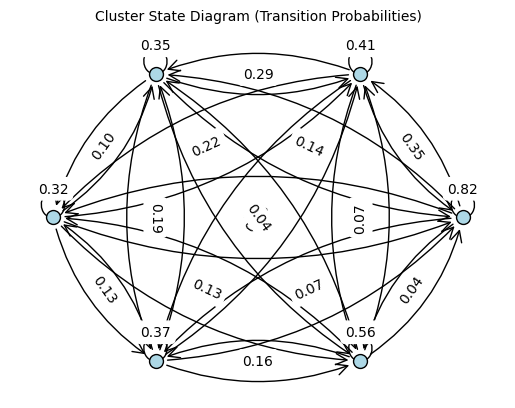

target_cluster         1         2         3         4         5         6
source_cluster                                                            
1               0.821407  0.133333  0.022630  0.015902  0.006116  0.000612
2               0.347674  0.412791  0.125581  0.058140  0.046512  0.009302
3               0.138767  0.292952  0.348018  0.059471  0.151982  0.008811
4               0.132013  0.221122  0.099010  0.316832  0.151815  0.079208
5               0.067358  0.134715  0.194301  0.126943  0.365285  0.111399
6               0.035019  0.073930  0.038911  0.128405  0.159533  0.564202


In [60]:
plot_State_Diagram(probs)

In [61]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

def plot_Markov_with_scalable_loops(probs, node_size=300, loop_radius_factor=0.5):
    """
    Plots a Markov state diagram with self-loops that scale with node size.
    
    Parameters:
    - probs: DataFrame of transition probabilities (rows=source, columns=target)
    - node_size: size of nodes
    - loop_radius_factor: factor controlling self-loop radius relative to node size
    """
    
    G = nx.DiGraph()
    
    # Add nodes
    for state in probs.index:
        G.add_node(state)
    
    # Add edges with weights
    for src in probs.index:
        for dst in probs.columns:
            p = probs.loc[src, dst]
            if p > 0:
                G.add_edge(src, dst, weight=p)
    
    # Layout
    pos = nx.circular_layout(G)
    
    fig, ax = plt.subplots(figsize=(8,6))
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color="lightblue", edgecolors="black", ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=12, ax=ax)
    
    # Draw normal edges
    for u, v, d in G.edges(data=True):
        if u != v:
            nx.draw_networkx_edges(
                G, pos, edgelist=[(u,v)],
                arrowstyle='->',
                arrowsize=15,
                width=d['weight']*5,
                connectionstyle= 'arc3,rad=0.1',
                edge_color='black',
                ax=ax
            )
    
    # Draw self-loops with scalable radius
    for node in G.nodes():
        if G.has_edge(node, node):
            x, y = pos[node]
            # radius scales with node size
            radius = loop_radius_factor * (node_size ** 0.5) / 100
            loop = FancyArrowPatch(
                (x, y), (x, y),
                connectionstyle=f"arc3,rad={radius}",
                arrowstyle='->',
                mutation_scale=15 + G[node][node]['weight']*10,
                lw=G[node][node]['weight']*2,
                color='black'
            )
            ax.add_patch(loop)
    
    # Draw edge labels
    #edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
    #nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, ax=ax)
    
    plt.title("Markov State Diagram with Scalable Self-Loops", fontsize=14)
    plt.axis('off')
    plt.show()


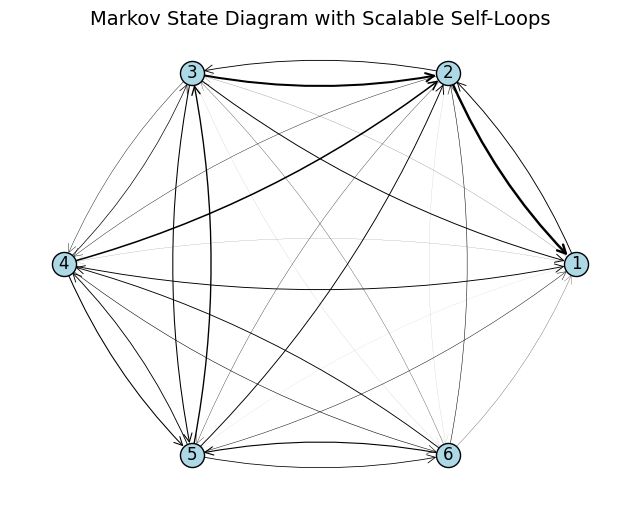

In [62]:
plot_Markov_with_scalable_loops(probs)

### Chord Diagram

In [63]:
from mpl_chord_diagram import chord_diagram
import matplotlib.pyplot as plt

def compute_chord_diagram(counts, probs, custom_color_map):
    def rgb_to_hex(rgb):
        return '#{:02x}{:02x}{:02x}'.format(*(int(c*255) for c in rgb))
        
    color_map_hex = {k: rgb_to_hex(v) for k, v in custom_color_map.items()}
    #print(color_map_hex)

    #Extract cluster labels
    labels = [str(l) for l in counts.index]  # convert to string for display

    # Compute N per node (sum of outgoing transitions)
    N_counts = counts.sum(axis=1)

    # Create node labels including
    labels_with_N = [f"Cluster {label}\nN={N_counts[label]}" for label in counts.index]

    #Compute Diagram
    chord_diagram(probs, names=labels_with_N, wrap_labels=True, use_gradient=True, alpha=0.7, colors = list(color_map_hex.values()))

    #Format & Show
    plt.title("Cluster Transition Chord Diagram", fontsize=14, y=1.1)
    plt.tight_layout()
    if store_figures:
        plt.savefig(os.path.join(figure_storage, f'PsAID_{describe_clusters}_ChortDiagram.png'))
    plt.show()

   # print(counts)
   # print(probs)


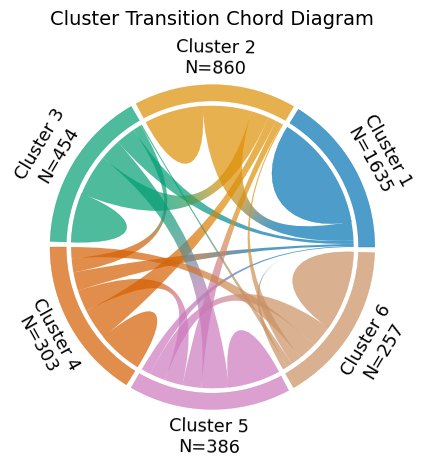

In [64]:
compute_chord_diagram(counts, probs, custom_color_map)